[Previous: Start Here](00_Start_Here.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 2: Quantum Logic Gates](02_Quantum_Logic_Gates.ipynb)

# Module 1: The Qubit & Superposition

**Learning objectives.** After this module you can:

* write a qubit state as a vector of two complex amplitudes and check it is normalised;
* locate any single-qubit state on the Bloch sphere from its angles $\theta$ and $\phi$;
* explain what measurement does to a superposition, and why you need many *shots* to see probabilities;
* build, draw and simulate your first quantum circuit in Qiskit.

**Prerequisites.** Run the environment check in [Start Here](00_Start_Here.ipynb).

## 1. The analogy: coins vs spinning coins

In classical computing the unit of information is a **bit**: a coin lying flat, either Heads ($0$) or Tails ($1$).

A **qubit** is like a coin spinning on the table. While it spins it is not Heads *or* Tails. Only when you slap
your hand down on it (**measurement**) is it forced to become one or the other.
The spinning state is called a **superposition**.

The analogy has one gap, and the gap is the whole subject: a spinning coin is *ignorance* about a definite fact,
but a qubit in superposition is a *definite state* described by two numbers called **amplitudes**.
Amplitudes can be negative or complex, and they can cancel each other out. A spinning coin can never do that.
Hold this thought until Module 4.

## 2. The mathematics: state vectors and Dirac notation

Quantum states are vectors. We write them in **Dirac** ("bra-ket") notation. The two classical states of a qubit are

$$|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}, \qquad |1\rangle = \begin{pmatrix} 0 \\ 1 \end{pmatrix}.$$

A general qubit state $|\psi\rangle$ is a linear combination of these:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle = \begin{pmatrix} \alpha \\ \beta \end{pmatrix}, \qquad \alpha, \beta \in \mathbb{C}.$$

$\alpha$ and $\beta$ are the **probability amplitudes**. When you measure, you get $0$ with probability $|\alpha|^2$
and $1$ with probability $|\beta|^2$ (this is the **Born rule**, Module 4). Probabilities must add to one, so every valid state obeys

$$|\alpha|^2 + |\beta|^2 = 1.$$

The most famous superposition is the equal one, called $|+\rangle$:

$$|+\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle = \begin{pmatrix} 1/\sqrt2 \\ 1/\sqrt2 \end{pmatrix}.$$

In [1]:
import numpy as np
from qiskit.quantum_info import Statevector

# Build three states directly from their amplitudes
ket0    = Statevector([1, 0])
ket1    = Statevector([0, 1])
ket_plus = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])

for name, state in [("|0>", ket0), ("|1>", ket1), ("|+>", ket_plus)]:
    print(f"{name}  amplitudes = {np.round(state.data, 3)}")
    print(f"     probabilities = {state.probabilities_dict()}")
    print(f"     normalised?   = {np.isclose(sum(abs(state.data)**2), 1)}\n")

# Qiskit can render kets nicely:
display(ket_plus.draw('latex'))

|0>  amplitudes = [1.+0.j 0.+0.j]
     probabilities = {np.str_('0'): np.float64(1.0)}
     normalised?   = True

|1>  amplitudes = [0.+0.j 1.+0.j]
     probabilities = {np.str_('1'): np.float64(1.0)}
     normalised?   = True

|+>  amplitudes = [0.707+0.j 0.707+0.j]
     probabilities = {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}
     normalised?   = True



<IPython.core.display.Latex object>

In [2]:
# What happens if the amplitudes are NOT normalised? Qiskit lets you build it,
# but is_valid() tells you it is not a physical state.
bad = Statevector([1, 1])
print("Is [1, 1] a valid state?", bad.is_valid())
print("Fix it by dividing by its length:", np.round((bad / np.linalg.norm(bad.data)).data, 3))

Is [1, 1] a valid state? False
Fix it by dividing by its length: [0.707+0.j 0.707+0.j]


> **What to notice.** `|+>` has amplitudes $0.707 = 1/\sqrt2$, not $0.5$. Amplitudes are *square roots* of probabilities.
> Squaring $0.707$ gives the 50 % you expect.

## 3. The Bloch sphere: a map of every single-qubit state

Two complex numbers are four real numbers, but normalisation removes one and a *global phase* (multiplying the whole state by $e^{i\gamma}$)
is physically invisible, which removes another. Two real numbers remain, and two numbers are a point on a sphere:

$$|\psi\rangle = \cos\frac{\theta}{2}\,|0\rangle + e^{i\phi}\sin\frac{\theta}{2}\,|1\rangle$$

* $\theta \in [0,\pi]$ is the **latitude** measured from the north pole: $\theta=0$ is $|0\rangle$, $\theta=\pi$ is $|1\rangle$, $\theta=\pi/2$ is the equator.
* $\phi \in [0, 2\pi)$ is the **longitude**, the *relative phase* between $|0\rangle$ and $|1\rangle$.

Six states are worth memorising because they sit on the axes:

| Axis | $+$ direction | $-$ direction |
|------|---------------|---------------|
| Z | $\lvert 0\rangle$ (north pole) | $\lvert 1\rangle$ (south pole) |
| X | $\lvert +\rangle = \tfrac{1}{\sqrt2}(\lvert 0\rangle + \lvert 1\rangle)$ | $\lvert -\rangle = \tfrac{1}{\sqrt2}(\lvert 0\rangle - \lvert 1\rangle)$ |
| Y | $\lvert i\rangle = \tfrac{1}{\sqrt2}(\lvert 0\rangle + i\lvert 1\rangle)$ | $\lvert -i\rangle = \tfrac{1}{\sqrt2}(\lvert 0\rangle - i\lvert 1\rangle)$ |

Every state on the equator gives 50/50 when measured. What distinguishes them is the *phase* $\phi$, which a plain measurement cannot see.
Module 4 shows how to see it anyway.

Qubit 0 = |0>,  1 = |1>,  2 = |+>,  3 = |->,  4 = |i>,  5 = |-i>


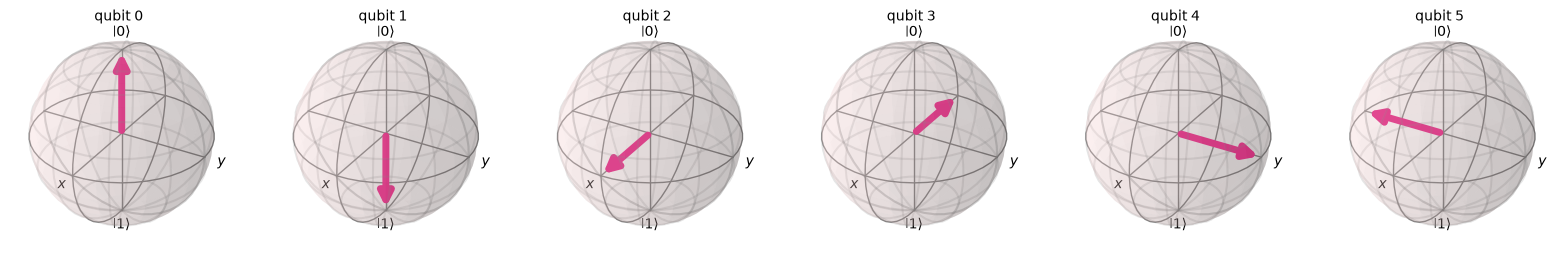

In [3]:
from qiskit.visualization import plot_bloch_multivector

# Qiskit labels: '0' '1' '+' '-' 'r' (=|i>) 'l' (=|-i>).
# from_label reads right-to-left: rightmost character is qubit 0.
six_states = Statevector.from_label('lr-+10')

print("Qubit 0 = |0>,  1 = |1>,  2 = |+>,  3 = |->,  4 = |i>,  5 = |-i>")
plot_bloch_multivector(six_states)

interactive(children=(FloatSlider(value=1.5707963267948966, description='θ (latitude)', max=3.141592653589793,…

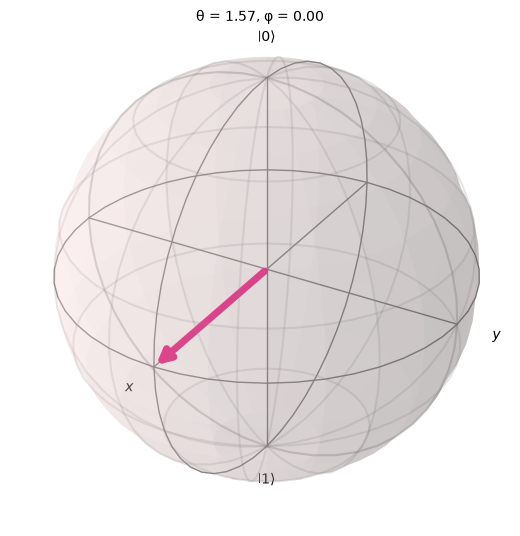

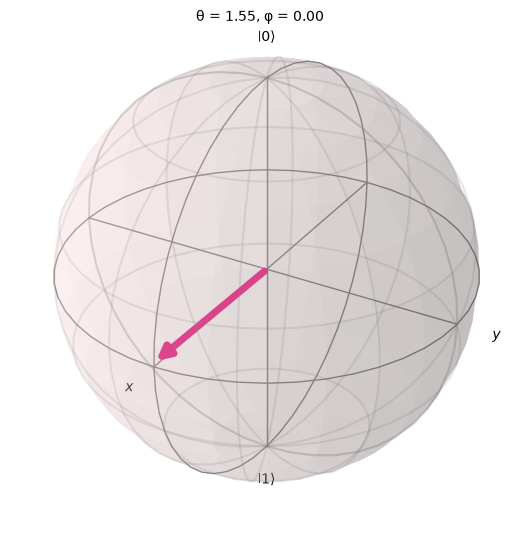

In [4]:
# Interactive: pick theta and phi, see the state, its amplitudes and its probabilities.
%matplotlib inline
from ipywidgets import interact, FloatSlider
from qiskit.visualization import plot_bloch_vector

def show_state(theta, phi):
    alpha = np.cos(theta / 2)
    beta  = np.exp(1j * phi) * np.sin(theta / 2)
    state = Statevector([alpha, beta])
    print(f"alpha = {alpha: .3f}          beta = {beta: .3f}")
    print(f"P(0)  = {abs(alpha)**2: .3f}     P(1) = {abs(beta)**2: .3f}")
    # Cartesian coordinates of the point on the sphere
    x, y, z = np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)
    display(plot_bloch_vector([x, y, z], title=f"θ = {theta:.2f}, φ = {phi:.2f}"))

interact(show_state,
         theta=FloatSlider(min=0, max=np.pi, step=0.05, value=np.pi/2, description='θ (latitude)'),
         phi=FloatSlider(min=0, max=2*np.pi, step=0.05, value=0, description='φ (phase)'));

> **What to notice.** Drag $\phi$ with $\theta = \pi/2$: the point circles the equator but $P(0)$ and $P(1)$ never change.
> Drag $\theta$: the probabilities slide smoothly from 100 % $|0\rangle$ to 100 % $|1\rangle$.

### Lab: Bloch Sphere Lab

The slider moves one state by hand. In the lab you move it the way a quantum computer does, with gates. Press H, then Z, then H again
and watch the path. Press RY with different angles. Try to land the arrow on the equator, then on the south pole. The matrix at the right is the
product of everything you pressed; Module 2 explains it.

In [5]:
from qclab import bloch_lab

bloch_lab()

## 4. Measurement: asking the qubit a question

Measuring a qubit in the standard (Z) basis returns **one classical bit** and **collapses** the state to the matching pole:

* outcome $0$ with probability $|\alpha|^2$, and the state becomes $|0\rangle$;
* outcome $1$ with probability $|\beta|^2$, and the state becomes $|1\rangle$.

Two consequences:

1. Measuring the *same* qubit again gives the same answer. The superposition is gone.
2. To learn $|\alpha|^2$ you must prepare the state fresh and measure it many times. Each repetition is a **shot**.

In [6]:
# Statevector.measure() simulates ONE measurement and returns (outcome, collapsed state)
print("Ten fresh |+> states, each measured once:")
outcomes = [ket_plus.measure()[0] for _ in range(10)]
print("  outcomes:", " ".join(outcomes))

print("\nMeasure one |+> state, then measure the collapsed state again five times:")
outcome, collapsed = ket_plus.measure()
print("  first outcome:", outcome, " collapsed state:", np.round(collapsed.data, 3))
print("  re-measurements:", " ".join(collapsed.measure()[0] for _ in range(5)))

Ten fresh |+> states, each measured once:
  outcomes: 1 1 0 1 1 0 1 1 0 1

Measure one |+> state, then measure the collapsed state again five times:
  first outcome: 0  collapsed state: [1.+0.j 0.+0.j]
  re-measurements: 0 0 0 0 0


## 5. Your first quantum circuit and simulator

A **quantum circuit** is a program: a list of gates applied to qubits, usually ending in measurements.
`AerSimulator` behaves like an ideal quantum computer: it runs the circuit for a chosen number of shots and returns how often each bitstring appeared.

The **Hadamard gate** `h` turns $|0\rangle$ into $|+\rangle$. So the circuit below is the spinning coin: prepare, then slap.

Quantum circuit:


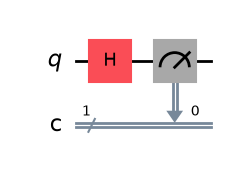

Counts after 1000 shots: {'0': 495, '1': 505}
Exact probabilities:     {np.str_('0'): np.float64(0.4999999999999999), np.str_('1'): np.float64(0.4999999999999999)}


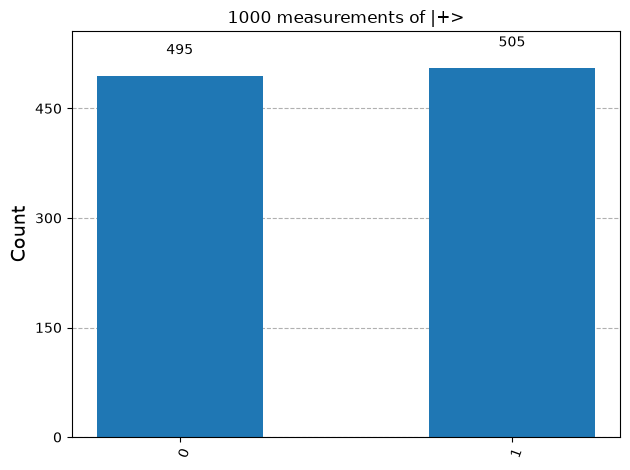

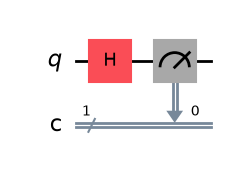

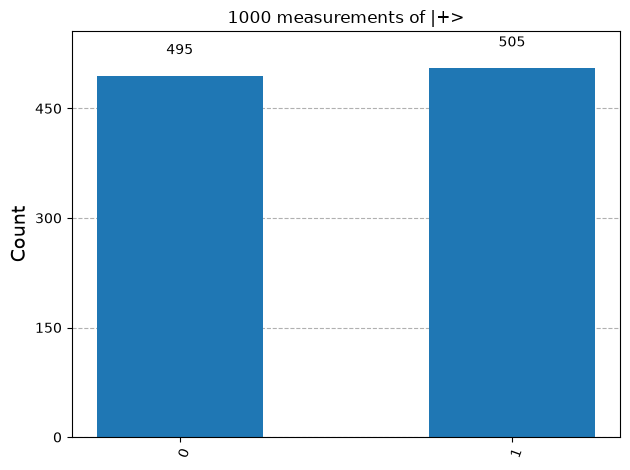

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

qc = QuantumCircuit(1, 1)   # 1 qubit, 1 classical bit for the result
qc.h(0)                     # |0> -> |+>
qc.measure(0, 0)            # measure qubit 0 into classical bit 0

print("Quantum circuit:")
display(qc.draw('mpl'))

simulator = AerSimulator()
counts = simulator.run(qc, shots=1000).result().get_counts()

print("Counts after 1000 shots:", counts)
print("Exact probabilities:    ", Statevector(qc.remove_final_measurements(inplace=False)).probabilities_dict())
plot_histogram(counts, title="1000 measurements of |+>")

In [8]:
# More shots -> better estimate of the true 50 %. Module 4 explores this properly.
for shots in [10, 100, 1000, 10000]:
    counts = simulator.run(qc, shots=shots).result().get_counts()
    p0 = counts.get('0', 0) / shots
    print(f"shots = {shots:>6}   estimated P(0) = {p0:.3f}   error = {abs(p0 - 0.5):.3f}")

shots =     10   estimated P(0) = 0.400   error = 0.100
shots =    100   estimated P(0) = 0.450   error = 0.050
shots =   1000   estimated P(0) = 0.478   error = 0.022
shots =  10000   estimated P(0) = 0.503   error = 0.003


> **What to notice.** The histogram is never *exactly* 500/500. Randomness is real, and the error shrinks roughly like $1/\sqrt{\text{shots}}$.

### Game: Guess the State (easy mode)

A hidden qubit is one of the six axis states. You have 300 shots. Measure in the Z basis first and look at the histogram: can you already rule some states out?
Measure in the X and Y bases to find the rest. Then guess. The hint button shows what your counts imply for the Bloch coordinates.

In [9]:
from qclab import guess_the_state

guess_the_state('easy')

## Try it yourself

**Exercise 1.** Build a `Statevector` that gives $0$ with probability 80 % and $1$ with probability 20 %. Verify with `probabilities_dict()`.

**Exercise 2.** Which $\theta$ produces that state? (Use the formula $P(0) = \cos^2(\theta/2)$.) Check with the slider above.

**Exercise 3.** Modify the circuit in section 5 so it *always* measures $1$. Which single gate do you need? Run 1000 shots to confirm.

<details><summary>Solutions</summary>

```python
# Exercise 1: amplitudes are square roots of probabilities
s = Statevector([np.sqrt(0.8), np.sqrt(0.2)])
print(s.probabilities_dict())          # {'0': 0.8, '1': 0.2}

# Exercise 2
theta = 2 * np.arccos(np.sqrt(0.8))    # ~ 0.927 rad ~ 53°
print(theta)

# Exercise 3: the X gate flips |0> to |1>
qc = QuantumCircuit(1, 1)
qc.x(0)
qc.measure(0, 0)
print(AerSimulator().run(qc, shots=1000).result().get_counts())   # {'1': 1000}
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [10]:
from qclab import quiz

quiz(1)

## Key takeaways

* A qubit state is two complex amplitudes $(\alpha, \beta)$ with $|\alpha|^2 + |\beta|^2 = 1$. Amplitudes are square roots of probabilities.
* Every single-qubit state is a point on the Bloch sphere given by latitude $\theta$ and phase $\phi$.
* Measurement returns one bit and collapses the state. Probabilities are only visible across many shots.
* `Statevector` gives exact amplitudes; `AerSimulator` gives realistic sampled counts.

**Next:** gates are rotations of the Bloch sphere. [Module 2](02_Quantum_Logic_Gates.ipynb) shows how to move the point around.

[Previous: Start Here](00_Start_Here.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 2: Quantum Logic Gates](02_Quantum_Logic_Gates.ipynb)